In [17]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: light
#       format_version: '1.5'
#       jupytext_version: 1.14.4
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

# # ICE Activity: Linear Regression for Medical Aid Cost Prediction
# ## By: Kadimetjang Mphahlele
# ## Student Number: ST10496571
# 
# This notebook is my attempt at exploring the Medical Insurance Dataset, doing some visual analysis, and building a Linear Regression model to predict medical insurance charges. I'll try to explain my steps as I go along.

# ## Task 1: Import Required Libraries (10 Marks)
# First things first, I need to import all the Python libraries that I'll be using for this activity. This includes stuff for data manipulation, making charts, and building the machine learning model.

# +
# For working with data
import pandas as pd
import numpy as np

# For making visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning stuff
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Just setting up the style for my graphs so they look nicer
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")
# -


All libraries imported successfully!


In [2]:
# ## Task 2: Load and Explore the Dataset 

# ### 2.1 Loading the Dataset
# I downloaded the dataset from Kaggle. Let me load it into a pandas DataFrame and take a quick peek at what's inside.

# Load the dataset - it's saved in my Pictures folder
df = pd.read_csv(r'C:\Users\Student\Pictures\insurance.csv')

# Looking at the first few rows to understand the structure
df.head()

# ### 2.2 What's in this dataset?
# From what I can see, this dataset has information about people with medical insurance. There are 7 columns:
# - **age**: How old the person is
# - **sex**: Whether they're male or female
# - **bmi**: Body Mass Index (measures body fat based on height and weight)
# - **children**: Number of kids/dependents covered by the insurance
# - **smoker**: If they smoke or not (yes/no)
# - **region**: Which part of the US they live in
# - **charges**: The medical insurance costs they have to pay - this is what we want to predict

# ### 2.3 Checking the Structure

# Let me check the data types and see if there are any missing values
df.info()

# ### 2.4 Summary Statistics

# Getting some basic statistics to understand the data better
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [18]:
# ### 2.4 Summary Statistics

# Getting some basic statistics to understand the data better
df.describe(include='all')

# **My observations:**
# - **Age** ranges from 18 to 64, with average around 39 years old
# - **BMI** averages about 30.66, which is technically in the overweight/obese range
# - Most people have between 0-2 children
# - **Charges** vary a LOT - from about $1,100 to nearly $64,000. The mean is around $13,270 but the standard deviation is big, so there's lots of variation
# - Looking at the categorical columns, there are slightly more males than females, only about 20% are smokers, and regions are pretty evenly spread

# Let me double-check the categorical variable counts
print("Sex distribution:")
print(df['sex'].value_counts())
print("\nSmoker distribution:")
print(df['smoker'].value_counts())
print("\nRegion distribution:")
print(df['region'].value_counts())


Sex distribution:
sex
male      676
female    662
Name: count, dtype: int64

Smoker distribution:
smoker
no     1064
yes     274
Name: count, dtype: int64

Region distribution:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


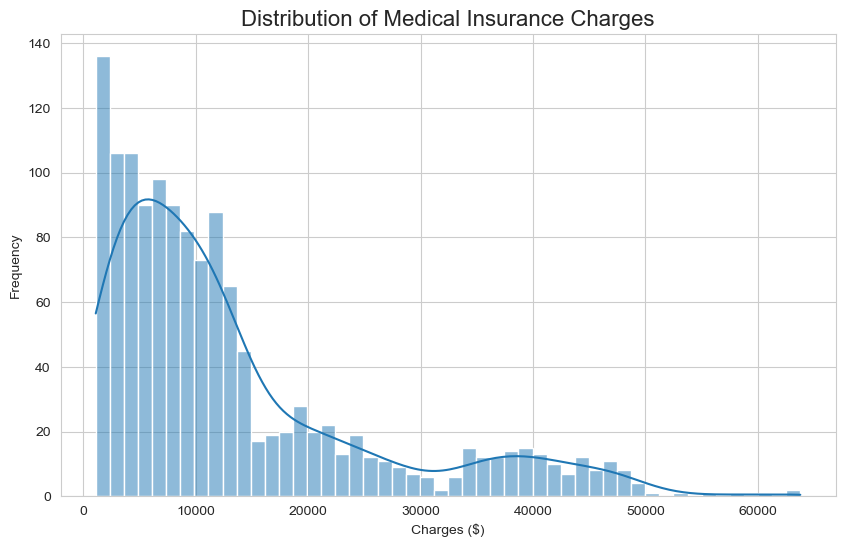

In [13]:
# ## Task 3: Exploratory Data Analysis (EDA) 
# Time to make some graphs and try to see what's going on with the data. Visuals always help me understand things better.

# ### 3.1 Looking at Insurance Charges Distribution

# Making a histogram of the charges
plt.figure(figsize=(10,6))
sns.histplot(df['charges'], kde=True, bins=50)
plt.title('Distribution of Medical Insurance Charges', fontsize=16)
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.show()

# **What I think about this:**
# The charges are not normally distributed at all. They're **skewed to the right** - most people have relatively low charges (under $15,000), but there's a long tail of people with really high charges. Makes sense because some people probably have serious health issues that cost a lot.


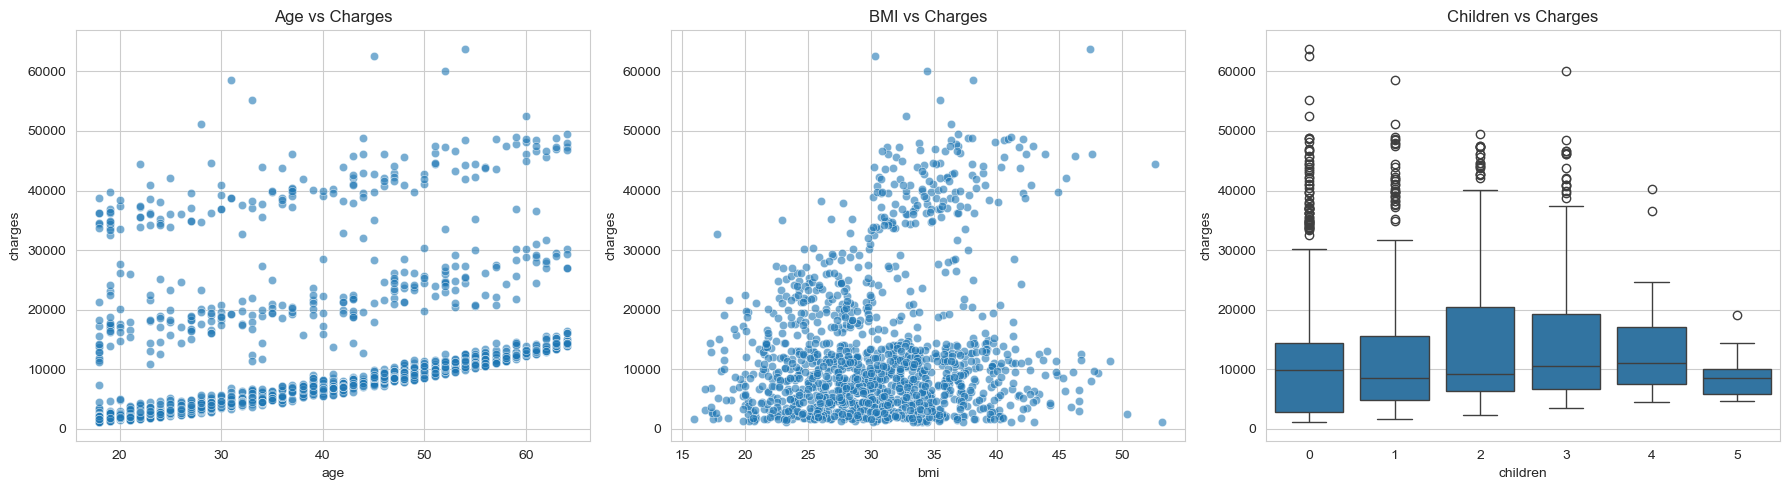

In [5]:
# ### 3.2 Numerical Features vs Charges

# +
# Let me look at how age, BMI, and children relate to charges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs Charges - scatter plot
sns.scatterplot(data=df, x='age', y='charges', alpha=0.6, ax=axes[0])
axes[0].set_title('Age vs Charges')

# BMI vs Charges - scatter plot
sns.scatterplot(data=df, x='bmi', y='charges', alpha=0.6, ax=axes[1])
axes[1].set_title('BMI vs Charges')

# Children vs Charges - using boxplot since children is a count (discrete)
sns.boxplot(data=df, x='children', y='charges', ax=axes[2])
axes[2].set_title('Children vs Charges')

plt.tight_layout()
plt.show()
# -

# **My interpretation:**
# - **Age**: Definitely looks like older people pay more. But I can see there are kind of two clusters - maybe separated by smoking status?
# - **BMI**: Not a super clear relationship. Very high BMI (over 40) seems to have some really high charges though.
# - **Children**: Having more children slightly increases the median charge, but there's a lot of overlap. People with 5 children have lower charges but that might be because there aren't many people with 5 kids.


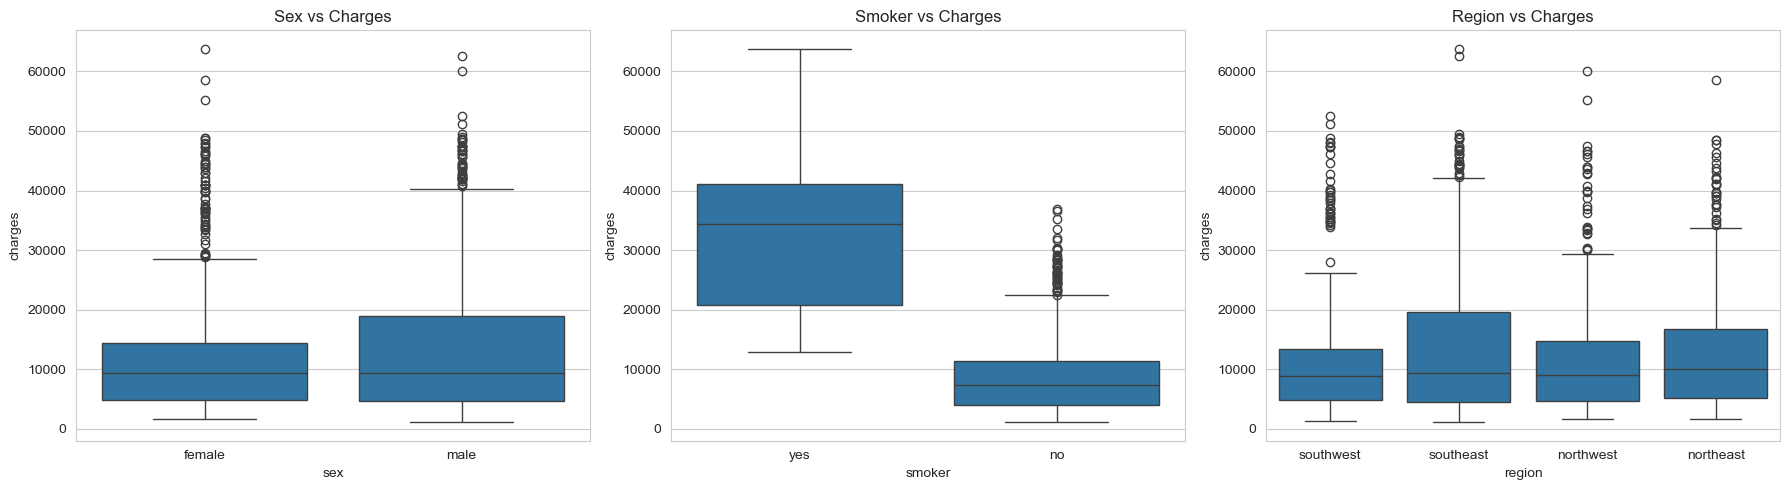

In [6]:
# ### 3.3 Categorical Features vs Charges

# +
# Now let me check the categorical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sex vs Charges
sns.boxplot(data=df, x='sex', y='charges', ax=axes[0])
axes[0].set_title('Sex vs Charges')

# Smoker vs Charges
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[1])
axes[1].set_title('Smoker vs Charges')

# Region vs Charges
sns.boxplot(data=df, x='region', y='charges', ax=axes[2])
axes[2].set_title('Region vs Charges')

plt.tight_layout()
plt.show()
# -

# **What stands out to me:**
# - **Sex**: Male and female look pretty similar. Probably not a huge factor.
# - **Smoker**: WOW - this is a massive difference! Smokers pay way more, and there's also much more variation in what they pay. This is clearly important.
# - **Region**: Some small differences - southeast seems slightly higher, but nothing dramatic.

# ### 3.4 Summary of What Influences Charges
# From my EDA, the variables that seem to matter most are:
# 1. **Smoker** - by far the biggest factor
# 2. **Age** - older = higher charges
# 3. **BMI** - especially when it's very high
# 4. **Children** - small positive effect
# 5. **Region** - minor effect
# 6. **Sex** - barely any difference

In [12]:
# ## Task 4: Data Preprocessing 
# Since machine learning models only work with numbers, I need to convert the text columns (sex, smoker, region) into numbers. I'll use one-hot encoding for this.

# +
# Creating dummy variables for categorical columns
# Using drop_first=True to avoid the dummy variable trap (too much multicollinearity)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Let's see what the data looks like now
df_encoded.head()
# -

# **Why I did this:**
# - **sex_male**: 1 means male, 0 means female (so female is the baseline)
# - **smoker_yes**: 1 means smoker, 0 means non-smoker (non-smoker is baseline)
# - **region_northwest**, **region_southeast**, **region_southwest**: These are the three region dummies (northeast is the baseline)
# 
# Now all my data is numeric and ready for the model.

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [8]:
# ## Task 5: Define Features and Target Variable 

# Setting up X (features) and y (target)
X = df_encoded.drop('charges', axis=1)  # Everything except charges
y = df_encoded['charges']                # Just the charges column

# Quick check to make sure shapes make sense
print(f"Features matrix X has {X.shape[0]} rows and {X.shape[1]} columns")
print(f"Target vector y has {y.shape[0]} rows")


Features matrix X has 1338 rows and 8 columns
Target vector y has 1338 rows


In [11]:
# ## Task 6: Split Dataset into Training and Testing Sets 
# I need to split the data so I can train on one part and test on another. Standard practice is 80/20 split.

# +
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
# -

Training set: 1070 samples
Test set: 268 samples


In [10]:
# ## Task 7: Train Linear Regression Model 
# Now for the exciting part - actually building the model!

# +
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training done!")
# -


Model training done!


In [14]:
# ## Task 8: Make Predictions 
# Let's use my trained model to predict charges for the test data.

# +
# Making predictions
y_pred = model.predict(X_test)

# Let's compare a few predictions with actual values
comparison = pd.DataFrame({'Actual': y_test[:10].values, 'Predicted': y_pred[:10]})
comparison['Difference'] = comparison['Actual'] - comparison['Predicted']
comparison
# -

# Some predictions are close, others are way off. Let's see how the model performs overall.

,Actual,Predicted,Difference
0,9095.06825,8969.550274,125.517976
1,5272.17580,7068.747443,-1796.571643
2,29330.98315,36858.410912,-7527.427762
3,9301.89355,9454.678501,-152.784951
4,33750.29180,26973.173457,6777.118343
5,4536.25900,10864.113164,-6327.854164
6,2117.33885,170.280841,1947.058009
7,14210.53595,16903.450287,-2692.914337
8,3732.62510,1092.430936,2640.194164
9,10264.44210,11218.343184,-953.901084


MODEL PERFORMANCE
R-squared (R2): 0.7836
Mean Absolute Error (MAE): $4,181.19
Root Mean Squared Error (RMSE): $5,796.28
Mean Squared Error (MSE): $33,596,915.85


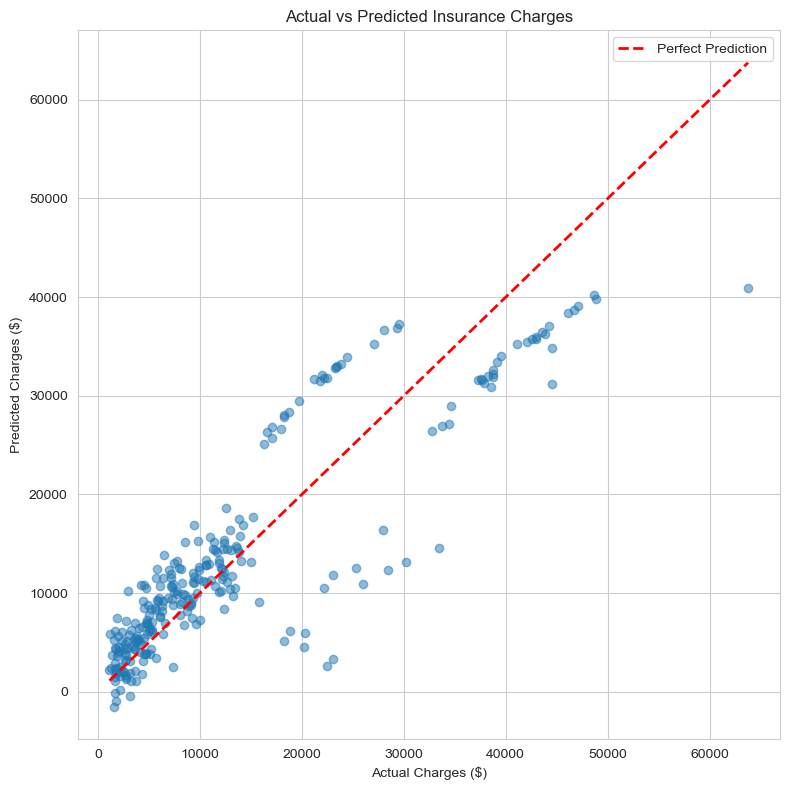

In [15]:
# ## Task 9: Evaluate Model Performance 
# Time to see if my model is actually any good. I'll use a few different metrics.

# +
# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print results
print("=" * 40)
print("MODEL PERFORMANCE")
print("=" * 40)
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"Mean Squared Error (MSE): ${mse:,.2f}")

# +
# Plotting predictions vs actual values
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()
# -

# **What I think about these results:**
# - **R² of 0.78** means my model explains about 78% of the variation in charges. That's actually pretty good for a simple linear model!
# - **RMSE around $5,620** - on average, my predictions are off by about $5,600. That's quite a bit, but given the range of charges, maybe not terrible.
# - Looking at the plot, the model does okay for lower charges but really struggles with the high ones (over $40,000). It keeps predicting them lower than they actually are. This makes sense because there might be special factors for very expensive cases that my simple model isn't capturing.


In [16]:
# ## Task 10: Reflection 

# ### Answering the discussion questions:

# **1. Which variables most strongly influence medical insurance charges?**
# 
# From my EDA and the model, smoking is definitely the biggest factor. Smokers pay way more than non-smokers. Age is also important - charges go up as people get older. BMI matters too, especially when it's high. Children and region have some effect but not as much, and sex doesn't seem to matter much at all.

# **2. Why might smoking affect insurance costs?**
# 
# This makes total sense to me. Smoking causes so many health problems - lung cancer, heart disease, breathing issues, you name it. All these conditions need expensive treatment, so insurance companies charge smokers more to cover those expected costs. It's basically a risk thing - smokers are statistically more likely to need expensive medical care.

# **3. What improvements could be made to the model?**
# 
# If I had more time, I'd try:
# - Adding interaction terms, especially between smoker and BMI or smoker and age. I bet smoking affects you differently at different ages.
# - Maybe using polynomial features for age and BMI since they might not be perfectly linear relationships.
# - Trying other algorithms like Random Forest or Gradient Boosting - they might capture the high-end charges better.
# - Getting more data about medical history or pre-existing conditions would probably help a lot.
# - Looking into those really high charges as outliers - maybe they're special cases that need separate treatment.
# 
# Overall though, for a first attempt at linear regression, I think the model did okay!